In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy.spatial import cKDTree

def naca_4digit_camber_line(x_over_c, m, p):
    """Mean camber line and slope for NACA 4-digit airfoils."""
    yc = np.zeros_like(x_over_c)
    dyc_dx = np.zeros_like(x_over_c)

    if m == 0.0 or p == 0.0:
        return yc, dyc_dx

    left = x_over_c < p
    right = ~left

    yc[left] = (m / (p**2)) * (2 * p * x_over_c[left] - x_over_c[left]**2)
    yc[right] = (m / ((1 - p)**2)) * (
        (1 - 2 * p) + 2 * p * x_over_c[right] - x_over_c[right]**2
    )

    dyc_dx[left] = (2 * m / (p**2)) * (p - x_over_c[left])
    dyc_dx[right] = (2 * m / ((1 - p)**2)) * (p - x_over_c[right])

    return yc, dyc_dx

def naca_5digit_camber_line(x_over_c, cl_design, p_digit, reflex=False):
    """Mean camber line and slope for NACA 5-digit airfoils.

    Supports the standard non-reflex families (third digit = 0), e.g. 23012.
    """
    yc = np.zeros_like(x_over_c)
    dyc_dx = np.zeros_like(x_over_c)

    non_reflex_table = {
        1: (0.0580, 361.4),
        2: (0.1260, 51.64),
        3: (0.2025, 15.957),
        4: (0.2900, 6.643),
        5: (0.3910, 3.230),
    }

    if reflex:
        raise NotImplementedError(
            "Reflexed 5-digit mean line (third digit = 1) is not implemented yet."
        )

    if p_digit not in non_reflex_table:
        raise ValueError("For 5-digit series, second digit must be in 1..5.")

    m, k1_base = non_reflex_table[p_digit]
    k1 = k1_base * (cl_design / 0.3)

    left = x_over_c < m
    right = ~left

    yc[left] = (k1 / 6.0) * (
        x_over_c[left]**3
        - 3 * m * x_over_c[left]**2
        + m**2 * (3 - m) * x_over_c[left]
    )
    yc[right] = (k1 / 6.0) * m**3 * (1 - x_over_c[right])

    dyc_dx[left] = (k1 / 6.0) * (
        3 * x_over_c[left]**2
        - 6 * m * x_over_c[left]
        + m**2 * (3 - m)
    )
    dyc_dx[right] = -(k1 / 6.0) * m**3

    return yc, dyc_dx

def naca_camber_line(x, code, chord=1.0):
    """Calculate camber line y_c and slope dy_c/dx for 4- and 5-digit NACA airfoils."""
    if not code.isdigit():
        raise ValueError("NACA code must contain digits only.")

    x_over_c = x / chord

    if len(code) == 4:
        m = int(code[0]) / 100.0
        p = int(code[1]) / 10.0
        t = int(code[2:]) / 100.0
        yc, dyc_dx = naca_4digit_camber_line(x_over_c, m, p)
        return yc, dyc_dx, t

    if len(code) == 5:
        cl_design = 0.15 * int(code[0])
        p_digit = int(code[1])
        reflex = int(code[2]) == 1
        t = int(code[3:]) / 100.0
        yc, dyc_dx = naca_5digit_camber_line(
            x_over_c, cl_design=cl_design, p_digit=p_digit, reflex=reflex
        )
        return yc, dyc_dx, t

    raise ValueError("NACA code must be 4 or 5 digits, e.g. '2412' or '23012'.")

def generate_naca_airfoil(code, num_points=200, chord=1.0):
    """Generate closed boundary coordinates for a NACA 4- or 5-digit airfoil."""
    x_c = np.linspace(0.0, chord, num_points)
    y_c, dyc_dx, thick = naca_camber_line(x_c, code, chord)

    yt = (thick / 0.2) * chord * (
        0.2969 * np.sqrt(x_c / chord)
        - 0.1260 * (x_c / chord)
        - 0.3516 * (x_c / chord) ** 2
        + 0.2843 * (x_c / chord) ** 3
        - 0.1015 * (x_c / chord) ** 4
    )

    theta = np.arctan(dyc_dx)

    x_u = x_c - yt * np.sin(theta)
    y_u = y_c + yt * np.cos(theta)
    x_l = x_c + yt * np.sin(theta)
    y_l = y_c - yt * np.cos(theta)

    # Closed polygon: upper surface LE->TE, then lower TE->LE.
    x_coords = np.concatenate([x_u, x_l[::-1]])
    y_coords = np.concatenate([y_u, y_l[::-1]])
    return np.column_stack((x_coords, y_coords))



def eval_distance(naca_code, query_pts):
    airfoil_pts = generate_naca_airfoil(naca_code, num_points=300)

    dx = 1e-3
    tree = cKDTree(airfoil_pts)
    x_offset = np.zeros_like(query_pts)
    y_offset = np.zeros_like(query_pts)
    x_offset[:,0] = dx
    y_offset[:,1] = dx
    
    distances, _ = tree.query(query_pts)
    distances_x, _ = tree.query(query_pts + x_offset)
    distances_y, _ = tree.query(query_pts + y_offset)
    distances_x_neg = tree.query(query_pts - x_offset)[0]
    distances_y_neg = tree.query(query_pts - y_offset)[0]

    airfoil_path = Path(airfoil_pts, closed=True)

    inside = airfoil_path.contains_points(query_pts)
    sign = np.where(inside, -1.0, 1.0)
    sdf = (distances * sign)#.reshape(xx.shape)

    inside_x = airfoil_path.contains_points(query_pts + x_offset)
    sign_x = np.where(inside_x, -1.0, 1.0)
    sdf_x = (distances_x * sign_x)#.reshape(xx.shape)

    inside_y = airfoil_path.contains_points(query_pts + y_offset)
    sign_y = np.where(inside_y, -1.0, 1.0)
    sdf_y = (distances_y * sign_y)#.reshape(xx.shape)

    
    inside_xn = airfoil_path.contains_points(query_pts - x_offset)
    sign_xn = np.where(inside_xn, -1.0, 1.0)
    sdf_xn = (distances_x_neg * sign_xn)#.reshape(xx.shape)

    inside_yn = airfoil_path.contains_points(query_pts - y_offset)
    sign_yn = np.where(inside_yn, -1.0, 1.0)
    sdf_yn = (distances_y_neg * sign_yn)#.reshape(xx.shape)

    sdf_grad_x = (sdf_x - sdf_xn) / dx / 2
    sdf_grad_y = (sdf_y - sdf_yn) / dx / 2
    sdf_grad_mag = np.sqrt(sdf_grad_x**2 + sdf_grad_y**2)

    return sdf, np.stack((sdf_grad_x, sdf_grad_y), axis=-1), sdf_grad_mag


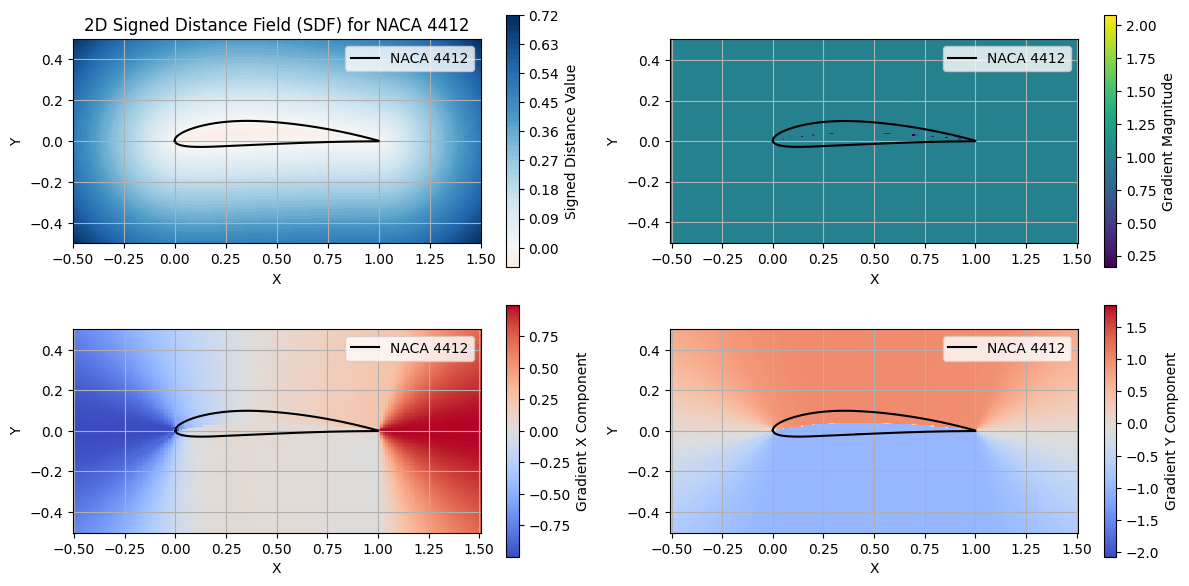

In [26]:

# --- Convert to Signed Distance Field ---
naca_code = "4412"  # Can be a 4-digit (e.g. 2412) or 5-digit (e.g. 23012) code
airfoil_pts = generate_naca_airfoil(naca_code, num_points=300)

# Shortest distance to boundary via KDTree
tree = cKDTree(airfoil_pts)

# Evaluation grid
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 0.5
grid_res = 150
x = np.linspace(x_min, x_max, grid_res)
y = np.linspace(y_min, y_max, grid_res)
xx, yy = np.meshgrid(x, y)
query_pts = np.c_[xx.ravel(), yy.ravel()]

sdf, sdf_grad, sdf_grad_mag = eval_distance(naca_code, query_pts)

# Plot signed distance field
fig, axis = plt.subplots(2,2,figsize=(12, 6), squeeze=False)

minD = np.min(sdf)
maxD = np.max(sdf)
vMin = -max(abs(minD), abs(maxD))
vMax = max(abs(minD), abs(maxD))

sc = axis[0,0].contourf(xx, yy, sdf, levels=60, cmap="RdBu", vmin = vMin, vmax = vMax)
fig.colorbar(sc, label="Signed Distance Value")
axis[0,0].set_title(f"2D Signed Distance Field (SDF) for NACA {naca_code}")

sc = axis[0,1].pcolormesh(xx, yy, sdf_grad_mag,cmap="viridis")
fig.colorbar(sc, label="Gradient Magnitude")

sc = axis[1,0].pcolormesh(xx, yy, sdf_grad[...,0], cmap="coolwarm")
fig.colorbar(sc, label="Gradient X Component")

sc = axis[1,1].pcolormesh(xx, yy, sdf_grad[...,1], cmap="coolwarm")
fig.colorbar(sc, label="Gradient Y Component")

for ax in axis.flatten():
    ax.plot(
        airfoil_pts[:, 0],
        airfoil_pts[:, 1],
        "k-",
        linewidth=1.5,
        label=f"NACA {naca_code}",
    )
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend()
fig.tight_layout()